# Kalman prediction and correction

Prepared for Shivam Singh · MathTech

## Theory
The six-state model stores center position, velocity and face size. Predictions bridge missing observations but are not measurements. Covariance expresses filter uncertainty under the assumed process model.

## Imports

In [1]:
from pathlib import Path
import sys
import numpy as np
import cv2
import matplotlib.pyplot as plt
from dataclasses import replace
from face_motion_lab.config.settings import Settings
from face_motion_lab.types import Box, Landmarks
from face_motion_lab.input.synthetic import demo_frame, SyntheticDetector
from face_motion_lab.pipeline import Pipeline
plt.rcParams.update({"figure.figsize": (9, 4), "axes.grid": True})
settings = Settings()


## Implementation

In [2]:
from face_motion_lab.tracking.kalman_tracker import KalmanBox
rng = np.random.default_rng(11)
truth = np.arange(100)*2.0
observations = truth + rng.normal(0, 5, len(truth))
filter = KalmanBox(Box(-25, -25, 50, 50))
estimates = []
for i, x in enumerate(observations):
    filter.predict(1/30)
    if not 45 <= i < 55:
        filter.correct(Box(x-25, -25, 50, 50))
    estimates.append(filter.box.center[0])


## Visualization

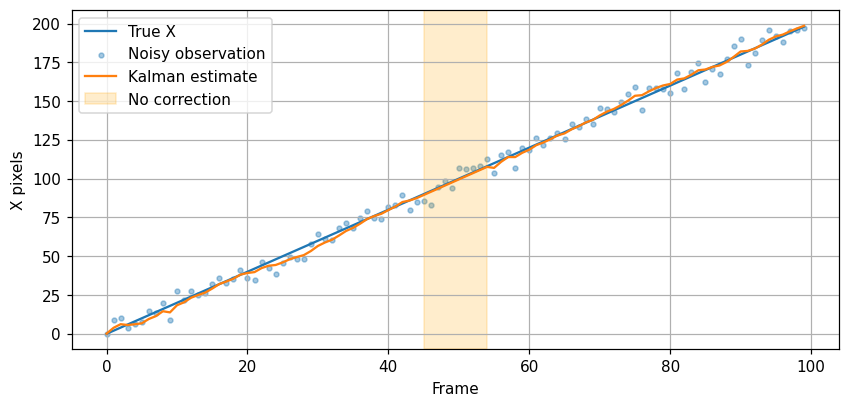

In [3]:
plt.plot(truth, label="True X")
plt.scatter(np.arange(100), observations, s=10, alpha=.4, label="Noisy observation")
plt.plot(estimates, label="Kalman estimate")
plt.axvspan(45, 54, color="orange", alpha=.2, label="No correction")
plt.xlabel("Frame"); plt.ylabel("X pixels"); plt.legend(); plt.show()


## Experiment

In [4]:
observed = np.ones(100, dtype=bool); observed[45:55] = False
raw_rmse = np.sqrt(np.mean((observations[observed]-truth[observed])**2))
filter_rmse = np.sqrt(np.mean((np.array(estimates)[observed]-truth[observed])**2))
print({"raw_rmse_px": float(raw_rmse), "filter_rmse_px": float(filter_rmse)})
assert np.linalg.eigvalsh(filter.P).min() > 0


{'raw_rmse_px': 4.576877508357603, 'filter_rmse_px': 1.9003513090643465}


## Observations
These RMSE values apply only to this seeded synthetic trajectory with known truth. Change speed abruptly and observe constant-velocity model lag.

## Conclusion
Prediction helps continuity but cannot certify face identity or unseen motion.